# Phase 1: Data Preparation & Alignment Check

This notebook verifies data readiness for the Inventory Optimization System. It validates the weekly scale, selected product families, actual/fitted/forecast alignment, and computes descriptive demand statistics to defend the choice of continuous review $(s,Q)$ vs periodic review $(R,S)$ policies.

All core computations are imported from the reusable `src/` modules.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in the path
sys.path.insert(0, os.path.abspath('..'))

from src.config import Config
from src.data_loader import load_train_data, load_test_data, filter_families, validate_weekly_alignment
from src.metrics import calculate_justification_statistics

## 1. Load Configurations

In [2]:
config = Config('../configs/inventory_config.yaml')
print("Demand Scale:", config.demand_scale)
print("Selected Families:", config.selected_families)
print("Weekly holding cost rate:", config.holding_cost_weekly)

Demand Scale: weekly
Selected Families: ['GROCERY I', 'BEVERAGES', 'CLEANING']
Weekly holding cost rate: 0.0028846153846153843


## 2. Load Training and Test Datasets

In [3]:
train_path = '../../Demand Forecasting System/data/actual_fitted_sales_on_train_final.csv'
test_path = '../../Demand Forecasting System/data/actual_fitted_sales_on_test_final.csv'

train_df = load_train_data(train_path, config)
test_df = load_test_data(test_path, config)

print("Training Set Shape:", train_df.shape)
print("Test Set Shape:", test_df.shape)

Training Set Shape: (2290, 4)
Test Set Shape: (30, 4)


## 3. Filter Families & Validate Alignment

In [4]:
train_df = filter_families(train_df, config.selected_families, config)
test_df = filter_families(test_df, config.selected_families, config)

# Validate Sunday week-ending alignment
validate_weekly_alignment(train_df, config)
print("Weekly alignment check successfully passed!")

Weekly alignment check successfully passed!


## 4. Policy-Choice Justification Statistics

We calculate the mean demand, standard deviation, Coefficient of Variation ($CV$), demand frequency, and zero-demand frequency to support the policy choices:
- Continuous review $(s,Q)$ for **Grocery I** and **Beverages**
- Periodic review $(R,S)$ for **Cleaning**

In [5]:
stats_df = calculate_justification_statistics(train_df, config)
stats_df

,family,Mean Weekly Demand,Weekly Standard Deviation,Weekly CV,Weekly Demand Frequency,Weekly Zero-Demand Frequency,Chosen Policy
0,BEVERAGES,9.461241e+05,381694.896193,0.403430,1.0,0.0,SQ
1,CLEANING,4.155624e+05,73498.654089,0.176865,1.0,0.0,RS
2,GROCERY I,1.476838e+06,333585.520786,0.225878,1.0,0.0,SQ


## 5. Demand and Forecast Plots

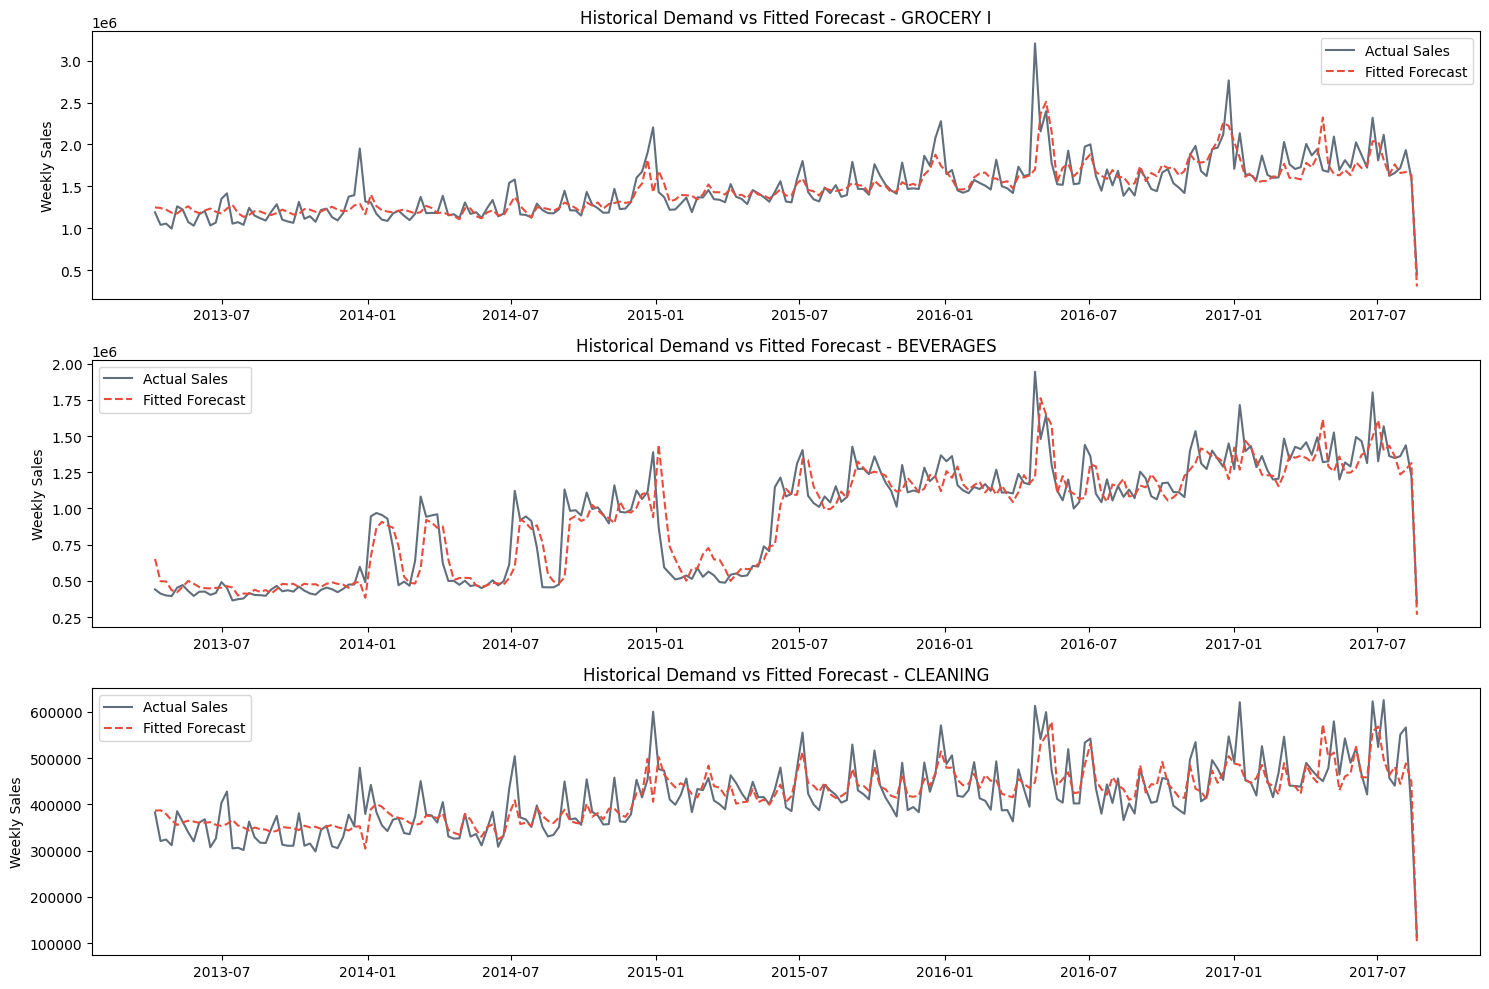

In [6]:
col_family = config.columns['family']
col_date = config.columns['date']
col_actual = config.columns['train_actual']
col_fitted = config.columns['train_fitted']

plt.figure(figsize=(15, 10))
for i, family in enumerate(config.selected_families, 1):
    fam_df = train_df[train_df[col_family] == family]
    plt.subplot(3, 1, i)
    plt.plot(fam_df[col_date], fam_df[col_actual], label='Actual Sales', color='#2C3E50', alpha=0.75)
    plt.plot(fam_df[col_date], fam_df[col_fitted], label='Fitted Forecast', color='#E74C3C', linestyle='--')
    plt.title(f"Historical Demand vs Fitted Forecast - {family}")
    plt.ylabel("Weekly Sales")
    plt.legend()

plt.tight_layout()
plt.show()